# 06. Running analyses through the worker API

The `worker/` service runs the same `AnalysisWorkflow` as a job behind a small HTTP API, so a laptop, a script or the worker's own web UI can drive analyses on a machine that has the credentials, the disk and the memory. This notebook drives it from Python with `requests`:

1. connect and check that the worker is ready;
2. submit a job (Sentinel-3 + Sentinel-2 with downscaling), follow its progress and read its log;
3. download the result and plot it;
4. list, cancel and delete jobs, and see how bad requests are rejected.

**Start a worker first**, for example `make worker` (port 8100) or `docker compose up -d`. This notebook reads `WORKER_URL` and `WORKER_API_TOKEN` from the environment, falling back to `worker/.env`; the token is never printed.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
import io
import time
import zipfile

import requests

worker_env = dotenv_values(ROOT / "worker" / ".env")
WORKER_URL = os.getenv("WORKER_URL", "http://127.0.0.1:8100").rstrip("/")
TOKEN = os.getenv("WORKER_API_TOKEN") or worker_env.get("WORKER_API_TOKEN")
session = requests.Session()
session.headers["Authorization"] = f"Bearer {TOKEN}"
# Polling reuses connections the server may close at the same moment: retry
# the requests that are safe to repeat.
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

session.mount("http://", HTTPAdapter(max_retries=Retry(total=3, backoff_factor=0.5, allowed_methods={"GET", "DELETE"})))
session.mount("https://", HTTPAdapter(max_retries=Retry(total=3, backoff_factor=0.5, allowed_methods={"GET", "DELETE"})))


def api(method, path, **kwargs):
    """Call the worker; the caller decides what each status code means."""
    response = session.request(method, f"{WORKER_URL}{path}", timeout=120, **kwargs)
    return response

## 1. Is the worker up, and ready?

`GET /health` needs no token: it is the liveness probe and reports the version and git commit running. `GET /health/ready` (token required) also checks free disk, the job database and authenticates against every data provider; it answers HTTP 503 when something is broken.

In [4]:
print(requests.get(f"{WORKER_URL}/health", timeout=10).json())

ready = api("GET", "/health/ready", params={"refresh": True})
print("HTTP", ready.status_code, "overall:", ready.json()["status"])
pd.DataFrame(ready.json()["checks"]).T

{'status': 'ok', 'version': '0.2.0', 'git_commit': '968972301370ce20ae71c997af3234de46790b1a'}


HTTP 200 overall: ok


,status,detail,expires_at
disk,ok,187.6 GB free (minimum 5.0 GB),NaN
job_database,ok,/tmp/claude-1000/-home-jshz-Sentinel-Orchestrator/0ad804c7-f4d7-4b...,NaN
credentials.cdse_oauth_client,ok,authenticated,None
credentials.cdse_account,ok,authenticated,None
credentials.earthdata,ok,authenticated; expires in 26 days,2026-11-05T08:56:21+00:00
credentials.cds,ok,authenticated,None
credentials.ads,not_configured,API URL/key not set,None
credentials.openaq,not_configured,OPENAQ_API_KEY not set,None


## 2. Submit a job

The simplest request body is an AOI, a period, sensors and a resolution; the worker builds the grids itself. Every option of `AnalysisRequest` is accepted, including `thermal_overpass`, `terrain_predictors` and `downscale`. The worker first checks the request against its limits (AOI size, products, estimated memory) and returns a job id at once.

In [5]:
job_request = {
    "aoi": {"west": 13.25, "south": 52.42, "east": 13.50, "north": 52.58},
    "start": "2026-08-08",
    "end": "2026-08-15",
    "sensors": ["sentinel3", "sentinel2"],
    "resolution_m": 100,
    "max_products_per_sensor": 6,
    "sentinel2_source": "stac_cog",
    "s2_cloud_cover_max": 60,
    "thermal_overpass": "day",
    "terrain_predictors": True,
    "downscale": {"model": "local_trees"},
}
submitted = api("POST", "/jobs", json=job_request, params={"name": "notebook 06: Berlin downscaling"})
print(submitted.status_code, submitted.json())
job_id = submitted.json()["job_id"]

200 {'job_id': 'c758ca6a-de03-41a5-b4d2-739c5e7c1c65', 'status': 'PENDING'}


### Follow progress

`GET /jobs/{id}` returns the status (`PENDING`, `RUNNING`, `SUCCEEDED`, `FAILED` or `CANCELLED`), the latest progress per sensor, timestamps and, once finished, metrics: duration, peak memory and how many products were skipped after failing.

In [6]:
last = None
while True:
    job = api("GET", f"/jobs/{job_id}").json()
    progress = job["progress"]
    line = f"{job['status']:9s} {progress['sensor']} {progress['done']}/{progress['total']}" if progress else job["status"]
    if line != last:
        print(time.strftime("%H:%M:%S"), line)
        last = line
    if job["status"] in ("SUCCEEDED", "FAILED", "CANCELLED"):
        break
    time.sleep(5)

{key: job[key] for key in ("status", "error_message", "started_at", "finished_at", "metrics")}

01:55:55 RUNNING


01:56:45 RUNNING   sentinel3 6/6


01:59:20 RUNNING   sentinel2 6/6


02:00:20 SUCCEEDED sentinel2 6/6


{'status': 'SUCCEEDED',
 'error_message': None,
 'started_at': '2026-10-09T23:55:55.505937+00:00',
 'finished_at': '2026-10-10T00:00:16.402019+00:00',
 'metrics': {'peak_rss_mb': 519.4, 'duration_s': 260.9, 'failed_products': 0}}

Every job keeps its own log, readable while it runs:

In [7]:
print(api("GET", f"/jobs/{job_id}/log", params={"lines": 20}).text)
if job["status"] != "SUCCEEDED":
    raise RuntimeError(f"the job ended {job['status']}: {job['error_message']}")

2026-10-10 01:55:59,131 INFO [app.jobs] [job c758ca6a] Job started (citycube 0.2.0, commit 968972301370ce20ae71c997af3234de46790b1a)
2026-10-10 01:56:03,525 INFO [citycube.workflow.runner] [job c758ca6a] sentinel3: 17 candidate products, 15 cover at least 30% of the AOI, 6 selected
2026-10-10 01:56:04,760 INFO [citycube.workflow.runner] [job c758ca6a] sentinel2: 6 candidate products, 6 cover at least 30% of the AOI, 6 selected
2026-10-10 01:56:04,760 INFO [citycube.workflow.runner] [job c758ca6a] sentinel3: acquiring 6 products
2026-10-10 01:56:41,632 INFO [citycube.workflow.runner] [job c758ca6a] sentinel3: prepared 6 acquisitions
2026-10-10 01:56:41,632 INFO [citycube.workflow.runner] [job c758ca6a] sentinel2: acquiring 6 products
2026-10-10 01:59:16,694 INFO [citycube.workflow.runner] [job c758ca6a] sentinel2: prepared 3 acquisitions
2026-10-10 01:59:31,076 INFO [citycube.workflow.runner] [job c758ca6a] Downscaling 6 scenes per scene with local_trees
2026-10-10 02:00:13,468 WARNING 

## 3. Download and use the result

`GET /jobs/{id}/result` streams a zip of the result directory: one Zarr store per cube (`cube`, `thermal_cube`, `predictors/<sensor>`, `terrain`, `downscaled`) plus `request.json` and `provenance.json`.

In [8]:
download = api("GET", f"/jobs/{job_id}/result")
target = OUT / "06_worker_result"
with zipfile.ZipFile(io.BytesIO(download.content)) as archive:
    archive.extractall(target)
print(f"{len(download.content) / 1e6:.1f} MB:", sorted(p.name for p in target.iterdir()))

import json
import citycube as cc

provenance = json.loads((target / "provenance.json").read_text())
print("produced by", provenance["software"], "| downscaled scenes:", provenance["downscaling"]["scenes"])
downscaled = cc.open_zarr(target / "downscaled.zarr").load()
coarse = cc.open_zarr(target / "cube.zarr").load()

6.0 MB: ['cube.zarr', 'downscaled.zarr', 'predictor_cube.zarr', 'predictors', 'provenance.json', 'request.json', 'terrain.zarr', 'thermal_cube.zarr']


produced by {'git_commit': '968972301370ce20ae71c997af3234de46790b1a', 'git_dirty': True, 'version': '0.2.0'} | downscaled scenes: 5


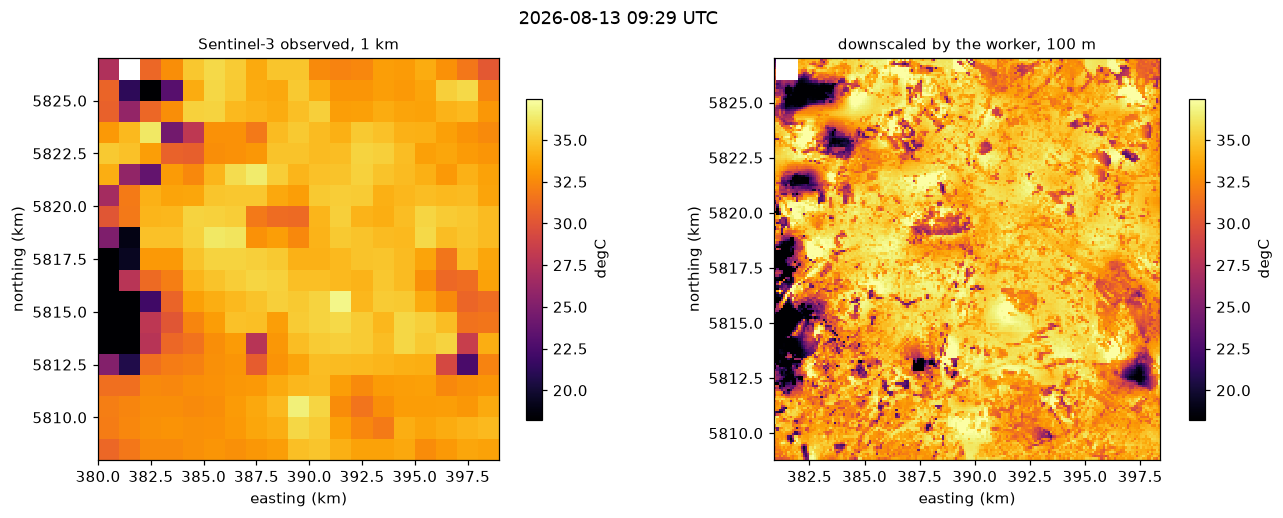

In [9]:
index = int(downscaled["lst_downscaled"].notnull().sum(["y", "x"]).argmax())
when = downscaled.time.values[index]
low, high = np.nanpercentile(downscaled["lst_downscaled"].isel(time=index).values, [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
show_map(axes[0], coarse["lst"].sel(time=when), "Sentinel-3 observed, 1 km", label="degC", vmin=low, vmax=high)
show_map(axes[1], downscaled["lst_downscaled"].isel(time=index), "downscaled by the worker, 100 m", label="degC", vmin=low, vmax=high)
fig.suptitle(pd.Timestamp(when).strftime("%Y-%m-%d %H:%M UTC"))
fig.savefig(FIGURES / "06_worker_result.png", bbox_inches="tight")
plt.show()

## 4. Managing jobs

### List

In [10]:
pd.DataFrame(api("GET", "/jobs").json())[["job_id", "name", "status", "created_at", "metrics"]].head()

,job_id,name,status,created_at,metrics
0,c758ca6a-de03-41a5-b4d2-739c5e7c1c65,notebook 06: Berlin downscaling,SUCCEEDED,2026-10-09T23:55:55.497359+00:00,"{'peak_rss_mb': 519.4, 'duration_s': 260.9, 'failed_products': 0}"


### Rejected requests

Invalid requests and requests beyond the worker's limits are refused with HTTP 422 before anything is queued; the message says what to change.

In [11]:
bad = {**job_request, "thermal_overpass": "dusk"}
print(api("POST", "/jobs", json=bad).json()["detail"])

too_large = {**job_request, "aoi": {"west": 10.0, "south": 50.0, "east": 15.0, "north": 54.0}, "resolution_m": 20}
print(api("POST", "/jobs", json=too_large).json()["detail"])

Invalid request: thermal_overpass must be one of ('any', 'day', 'night')
Invalid request: Request too large: AOI is 152,214 km2 (limit 10,000 km2); estimated cube size is 386.0 GB (limit 8.0 GB); reduce the AOI, the period or max_products_per_sensor, or coarsen the predictor grid


### Cancel and delete

A pending job is cancelled at once; a running one within about a second, including any external tool it started. Finished jobs (and all their files) can be deleted; the worker also deletes them automatically after `JOB_RETENTION_DAYS`.

In [12]:
long_job = api("POST", "/jobs", json={**job_request, "start": "2026-07-01", "end": "2026-08-31", "max_products_per_sensor": 30}, params={"name": "to be cancelled"}).json()["job_id"]
while api("GET", f"/jobs/{long_job}").json()["status"] == "PENDING":
    time.sleep(1)
time.sleep(10)
print("cancel:", api("POST", f"/jobs/{long_job}/cancel").json())
while (status := api("GET", f"/jobs/{long_job}").json()["status"]) == "RUNNING":
    time.sleep(1)
print("status now:", status)

for finished in (long_job, job_id):
    print("delete:", api("DELETE", f"/jobs/{finished}").json())
print("after deletion:", api("GET", f"/jobs/{job_id}").status_code)

cancel: {'job_id': '4bdca8e4-9d5d-420d-a5bc-aecf522562fd', 'status': 'RUNNING', 'cancel_requested': True}


status now: CANCELLED
delete: {'job_id': '4bdca8e4-9d5d-420d-a5bc-aecf522562fd', 'deleted': True}
delete: {'job_id': 'c758ca6a-de03-41a5-b4d2-739c5e7c1c65', 'deleted': True}
after deletion: 404


## The same from the shell

```bash
TOKEN=...   # WORKER_API_TOKEN
curl -s localhost:8100/health
curl -s -H "Authorization: Bearer $TOKEN" localhost:8100/health/ready
curl -s -H "Authorization: Bearer $TOKEN" -H "Content-Type: application/json" \
     -d @request.json "localhost:8100/jobs?name=berlin"
curl -s -H "Authorization: Bearer $TOKEN" localhost:8100/jobs/$JOB_ID
curl -s -H "Authorization: Bearer $TOKEN" localhost:8100/jobs/$JOB_ID/log
curl -s -H "Authorization: Bearer $TOKEN" -o result.zip localhost:8100/jobs/$JOB_ID/result
curl -s -X POST -H "Authorization: Bearer $TOKEN" localhost:8100/jobs/$JOB_ID/cancel
curl -s -X DELETE -H "Authorization: Bearer $TOKEN" localhost:8100/jobs/$JOB_ID
```

The worker's web UI (served at the worker's root URL) offers the same operations: a map to draw the AOI, the job list with progress, logs, cancel, delete and download, and a readiness report in Settings.